In [1]:
import pandas as pd

# import data 
data = pd.read_csv("data/dataset-tbp.csv")

# head
data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# Eksplorasi Data

In [2]:
# data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

## Distribusi Variabel Target

Bankrupt?
0    6599
1     220
Name: count, dtype: int64


<Axes: title={'center': 'Distribusi Bankrupt?'}, xlabel='Bankrupt?'>

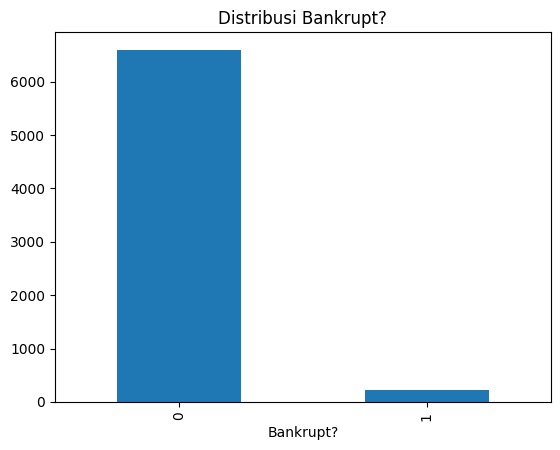

In [3]:
# dalam angka
print(data['Bankrupt?'].value_counts())

# visualisasi
data['Bankrupt?'].value_counts().plot(kind='bar', title='Distribusi Bankrupt?')

## Distribusi Variabel Fitur

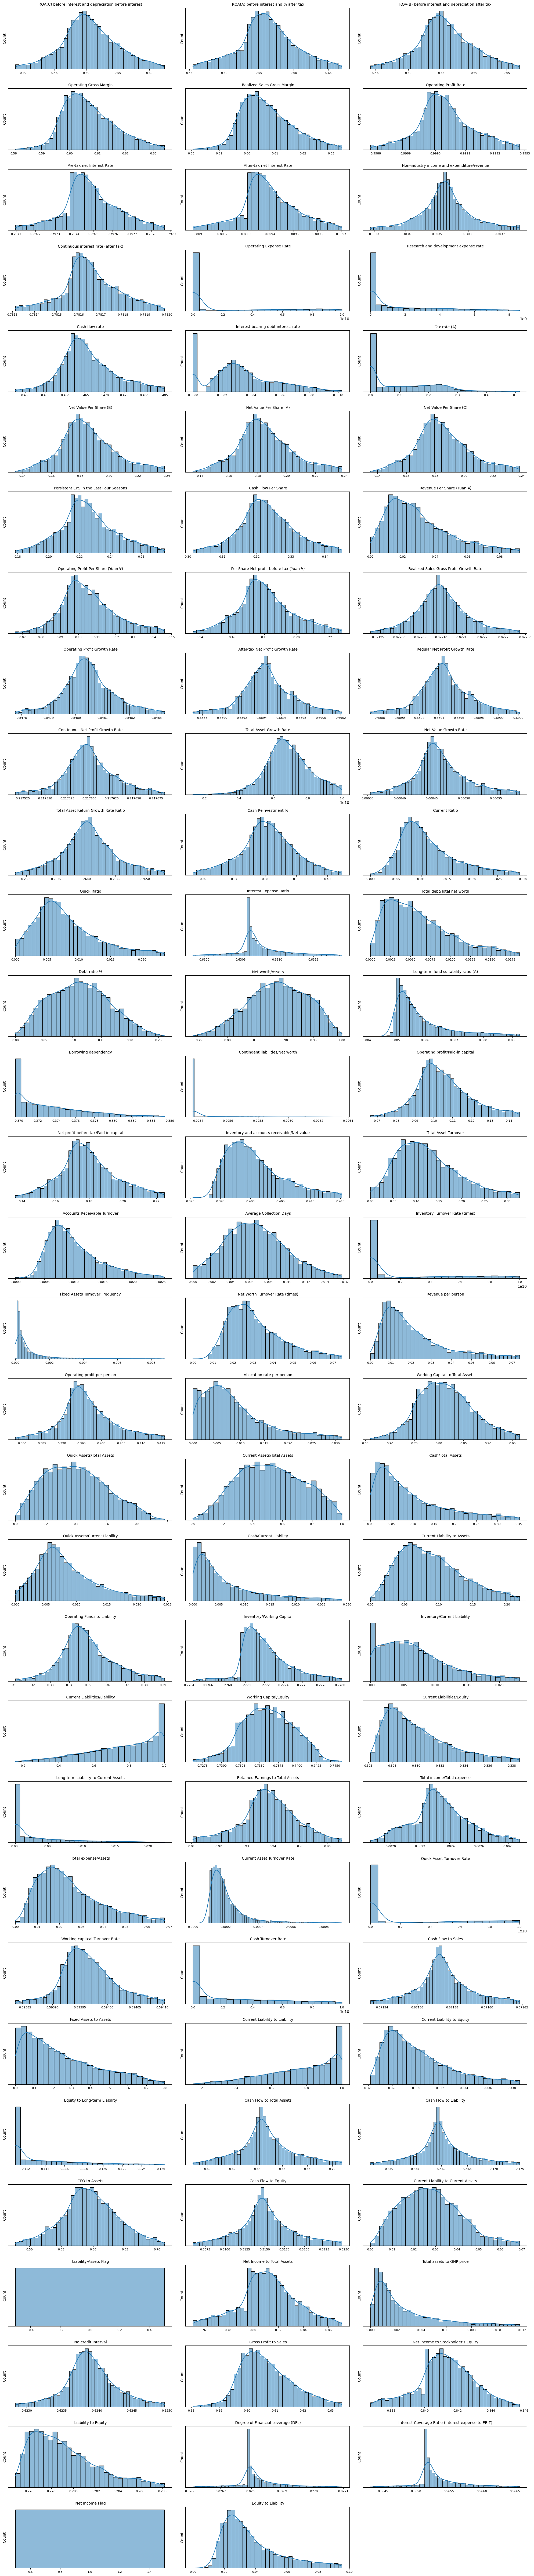

In [4]:
import seaborn as sns
import numpy as np
import math

import matplotlib.pyplot as plt

# Remove the target variable
feature_columns = [col for col in data.columns if col != 'Bankrupt?']

# Calculate grid dimensions - approximately a square grid
n_features = len(feature_columns)
n_cols = 3  # We'll use 3 columns
n_rows = math.ceil(n_features / n_cols)

# Set up the plot with a reasonable figure size
plt.figure(figsize=(20, n_rows * 3))

# Create histograms for each feature
for i, column in enumerate(feature_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Use a more robust approach to determine bin range for better visualization
    # Handle extreme values and outliers
    values = data[column].values
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    
    # Filter out extreme outliers for better visualization
    filtered_values = values[(values >= lower_bound) & (values <= upper_bound)]
    
    if len(filtered_values) > 0:  # If we have values after filtering
        sns.histplot(filtered_values, kde=True)
    else:  # If all values were filtered out, use original data
        sns.histplot(values, kde=True)
    
    plt.title(column, fontsize=10)
    plt.xlabel('')
    plt.yticks([])
    plt.xticks(fontsize=8)

plt.tight_layout()
plt.show()

# Feature Selection

## Tabel nilai korelasi

In [5]:
# melihat korelasi dengan target
correlation_matrix_target = data.corr()['Bankrupt?'].sort_values(ascending=False)
correlation_matrix_target

Bankrupt?                                                   1.000000
 Debt ratio %                                               0.250161
 Current Liability to Assets                                0.194494
 Borrowing dependency                                       0.176543
 Current Liability to Current Assets                        0.171306
                                                              ...   
 ROA(C) before interest and depreciation before interest   -0.260807
 ROA(B) before interest and depreciation after tax         -0.273051
 ROA(A) before interest and % after tax                    -0.282941
 Net Income to Total Assets                                -0.315457
 Net Income Flag                                                 NaN
Name: Bankrupt?, Length: 96, dtype: float64

## Melihat signifikansi dengan oneway-anova

In [6]:
from scipy.stats import f_oneway

num_cols = data.select_dtypes(include='number').columns.drop('Bankrupt?')
results = []
for col in num_cols:
    group0 = data[data['Bankrupt?']==0][col]
    group1 = data[data['Bankrupt?']==1][col]
    f_stat, p_val = f_oneway(group0, group1)
    results.append({'feature': col, 'f_stat': f_stat, 'p_value': p_val})

# Buat DataFrame hasil
import pandas as pd
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('p_value')

# Tampilkan fitur dengan p-value < 0.05 (signifikan)
print(results_df[results_df['p_value'] < 0.05])

                                              feature      f_stat  \
85                         Net Income to Total Assets  753.348894   
1              ROA(A) before interest and % after tax  593.228629   
2    ROA(B) before interest and depreciation after...  549.202093   
0    ROA(C) before interest and depreciation befor...  497.535121   
36                                       Debt ratio %  455.091151   
37                                   Net worth/Assets  455.091151   
18            Persistent EPS in the Last Four Seasons  345.267517   
67                  Retained Earnings to Total Assets  339.411396   
42              Net profit before tax/Paid-in capital  307.823235   
22           Per Share Net profit before tax (Yuan ¥)  288.185465   
59                        Current Liability to Assets  268.012458   
53                    Working Capital to Total Assets  263.987646   
89                 Net Income to Stockholder's Equity  230.861805   
39                               B

d:\Python\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


Buat dataframe baru dengan fitur-fitur signifikan

In [7]:
# dataframe baru dengan fitur signifikan
significant_features = results_df[results_df['p_value'] < 0.05]['feature'].tolist()
data_significant = data[significant_features + ['Bankrupt?']]

# tampilkan dataframe baru
data_significant.head()

,Net Income to Total Assets,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,ROA(C) before interest and depreciation before interest,Debt ratio %,Net worth/Assets,Persistent EPS in the Last Four Seasons,Retained Earnings to Total Assets,Net profit before tax/Paid-in capital,Per Share Net profit before tax (Yuan ¥),...,Total Asset Growth Rate,Cash Flow to Liability,Revenue per person,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Total assets to GNP price,Quick Asset Turnover Rate,Quick Ratio,Research and development expense rate,Bankrupt?
0,0.716845,0.424389,0.405750,0.370594,0.207576,0.792424,0.169141,0.903225,0.137757,0.138736,...,4.980000e+09,0.458609,0.034164,0.688979,0.688979,0.009219,6.550000e+09,0.001208,0.0,1
1,0.795297,0.538214,0.516730,0.464291,0.171176,0.828824,0.208944,0.931065,0.168962,0.169918,...,6.110000e+09,0.459001,0.006889,0.689693,0.689702,0.008323,7.700000e+09,0.004039,0.0,1
2,0.774670,0.499019,0.472295,0.426071,0.207516,0.792484,0.180581,0.909903,0.148036,0.142803,...,7.280000e+09,0.459254,0.028997,0.689463,0.689470,0.040003,1.022676e-03,0.005348,25500000.0,1
3,0.739555,0.451265,0.457733,0.399844,0.151465,0.848535,0.193722,0.906902,0.147561,0.148603,...,4.880000e+09,0.448518,0.015463,0.689110,0.689110,0.003252,6.050000e+09,0.002896,0.0,1
4,0.795016,0.538432,0.522298,0.465022,0.106509,0.893491,0.212537,0.913850,0.167461,0.168412,...,5.510000e+09,0.454411,0.058111,0.689697,0.689697,0.003878,5.050000e+09,0.003727,0.0,1


# Prepocessing

## Oversampling

In [10]:
import imblearn
from imblearn.over_sampling import SMOTE

# pisahkan fitur dan target
X = data_significant.drop('Bankrupt?', axis=1)
y = data_significant['Bankrupt?']

# inisialisasi SMOTE
smote = SMOTE(random_state=42)

# apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

In [11]:
# gabungkan kembali ke dalam satu dataframe
data_resampled = pd.concat([X_resampled, y_resampled], axis=1)

# cek distribusi setelah oversampling
print(data_resampled['Bankrupt?'].value_counts())

Bankrupt?
1    6599
0    6599
Name: count, dtype: int64


In [12]:
# splitting data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# print shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10558, 59)
X_test shape: (2640, 59)


# Modelling

## Decision Tree

In [13]:
## Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# inisialisasi model
dt = DecisionTreeClassifier(random_state=42)

# fit model
dt.fit(X_train, y_train)

# prediksi
y_pred = dt.predict(X_test)

# evaluasi
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[1245   75]
 [  45 1275]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1320
           1       0.94      0.97      0.96      1320

    accuracy                           0.95      2640
   macro avg       0.95      0.95      0.95      2640
weighted avg       0.95      0.95      0.95      2640

Accuracy: 0.9545454545454546


## Logistic Regression

In [14]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# inisialisasi model
lr = LogisticRegression(max_iter=1000, random_state=42)

# fit model
lr.fit(X_train, y_train)

# prediksi
y_pred_lr = lr.predict(X_test)

# evaluasi
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Confusion Matrix:
[[1010  310]
 [ 764  556]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.77      0.65      1320
           1       0.64      0.42      0.51      1320

    accuracy                           0.59      2640
   macro avg       0.61      0.59      0.58      2640
weighted avg       0.61      0.59      0.58      2640

Accuracy: 0.5931818181818181


## Random Forest

In [15]:
## Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# inisialisasi model
rf = RandomForestClassifier(random_state=42)

# fit model
rf.fit(X_train, y_train)

# prediksi
rf.fit(X_train, y_train)

# prediksi
y_pred_rf = rf.predict(X_test)

# evaluasi
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Confusion Matrix:
[[1267   53]
 [  11 1309]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.96      0.99      0.98      1320

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640

Accuracy: 0.9757575757575757
